In [84]:
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_absolute_error
from nltk.cluster.kmeans import KMeansClusterer
from nltk.cluster.util import euclidean_distance
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo
from imblearn.under_sampling import RandomUnderSampler

# fetch dataset
support2 = fetch_ucirepo(id=880)

import umap.umap_ as umap
import matplotlib.pyplot as plt

from models_II import *
from my_encodings import *


In [85]:
features = support2.data.features
targets = support2.data.targets

In [86]:
# --------------------------- Initialize dataset ------------------------------
# data (as pandas dataframes)
features = support2.data.features
targets = support2.data.targets


# join together as 1 df for EDA 
df = features.join(targets)
df = df.drop(columns=['death', 'hospdead', 'adlp', 'adls', 'scoma', 'totmcst', 'totcst', 'sps', 'aps', 'hday', \
                      'adlsc', 'prg2m', 'prg6m', 'charges', 'dzgroup', 'dnr', 'dnrday', 'urine',
                      'surv2m', 'surv6m']) # added surv2m, surv6m to drop; prevent data leakage

# drop rows where target = NaN
print(f'Before dropping NaNs in target: {df.shape[0]}')
df = df.dropna(subset=['sfdm2'])

print(f'After dropping NaNs in target: {df.shape[0]}')

# check remaining columns
print(df.columns)
print(len(df.columns))

Before dropping NaNs in target: 9105
After dropping NaNs in target: 7705
Index(['age', 'sex', 'dzclass', 'num.co', 'edu', 'income', 'avtisst', 'race',
       'diabetes', 'dementia', 'ca', 'meanbp', 'wblc', 'hrt', 'resp', 'temp',
       'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'sfdm2'],
      dtype='object')
25


Pipeline for encoding, scaling, and imputing NaNs

1) Separate numerical and categorical features
2) Encode categorical features
3) Split
4) Scale all features (train/test)
5) Impute (train/test)

In [87]:
# -------------------------------------- Encode categorical features ----------------------------------
# isolate categorical features
df_to_encode = df.copy()

''' DROPPING CLASS 3 '''
df_to_encode = df_to_encode[df_to_encode['sfdm2'] != 'Coma or Intub']

# get column names
numerical_feats = df_to_encode.select_dtypes(include=['number']).columns.tolist() # determine numerical columns

# keep numerica columns separate
numerical_df = df_to_encode[numerical_feats]

df_to_encode = df_to_encode.drop(numerical_feats, axis=1) # drop numerical columns

# dummy encode
dum_cols = ['sex', 'dzclass', 'race', 'ca']
df_to_encode = pd.get_dummies(df_to_encode, columns=dum_cols, dtype=int)

# ordinal encoding
income_order = {
    'under $11k': 0,
    '$11-$25k': 1,
    '$25-$50k': 2,
    '>$50k': 3
}

df_to_encode['income'] = df_to_encode['income'].map(income_order)

target_order = {
    'no(M2 and SIP pres)': 0, 
    'adl>=4 (>=5 if sur)': 1, 
    'SIP>=30': 2,
    '<2 mo. follow-up': 3    
}

df_to_encode['sfdm2'] = df_to_encode['sfdm2'].map(target_order)

# recombine dataframe
df = pd.concat([df_to_encode, numerical_df], axis=1)

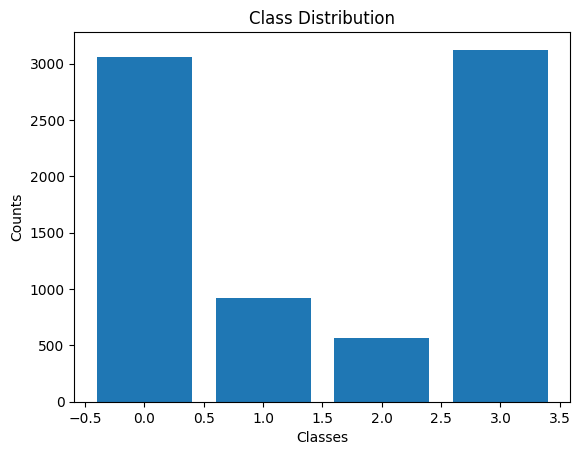

In [88]:
# observe class distribution

counts = df['sfdm2'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel("Classes")
plt.ylabel("Counts")
plt.title("Class Distribution")
plt.show()

In [89]:
# -------------------------------------- Split ----------------------------------
X = df.drop(columns=['sfdm2'])
y = df[['sfdm2']]

# split into training vs test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [90]:
# -------------------------------------- Scale all Features ----------------------------------
scaler = StandardScaler()
XS_train = scaler.fit_transform(X_train)
XS_test = scaler.transform(X_test)

In [91]:
# -------------------------------------- Impute ----------------------------------
imputer = KNNImputer(n_neighbors=10) # initialize imputer 

# training
XS_train = imputer.fit_transform(XS_train) # fit and transform training set 

# testing
XS_test = imputer.transform(XS_test)

In [92]:
# -------------------------------------- NaN Check ----------------------------------
train_df = pd.DataFrame(XS_train)
test_df = pd.DataFrame(XS_test)

print(f"Contains missing values xtrain: {train_df.isna().any().any()}")
print(f"Contains missing values xtest: {test_df.isna().any().any()}")
print(f"Contains missing values ytrain: {y_train.isna().any().any()}")
print(f"Contains missing values ytest: {y_test.isna().any().any()}")

Contains missing values xtrain: False
Contains missing values xtest: False
Contains missing values ytrain: False
Contains missing values ytest: False


In [93]:
counts = y_train.value_counts()
print(counts)

sfdm2
3        2509
0        2437
1         745
2         440
Name: count, dtype: int64


In [94]:
# -------------------------------------- Balance classes ----------------------------------

# 'Coma or Intub' class dropped in previous cell

class_balance = {
    0: 500,
    1: 500,
    3: 500
}

RUS = RandomUnderSampler(sampling_strategy=class_balance, random_state=42)

XS_train, y_train = RUS.fit_resample(XS_train, y_train)

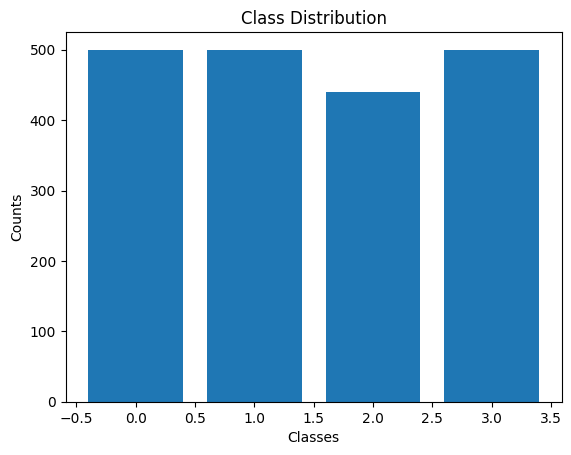

In [95]:
# observe class distribution
y_train_observe = y_train.squeeze()

counts = y_train_observe.value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel("Classes")
plt.ylabel("Counts")
plt.title("Class Distribution")
plt.show()

In [96]:
y_train_observe.value_counts()

sfdm2
0    500
1    500
3    500
2    440
Name: count, dtype: int64

### No PCA

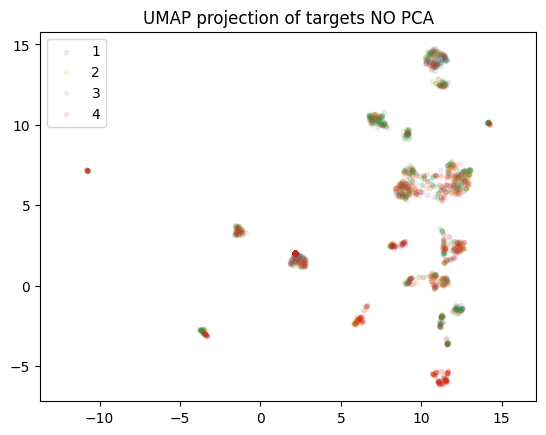

In [97]:
newXY = umap.UMAP().fit_transform(XS_train)

for i in range(np.max(y_train) + 1): 
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.', 
                alpha = 0.1, label = str(i + 1))
    
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets NO PCA')
plt.legend()
plt.show()

### WITHOUT PCA

---------------------------- MN LOGISTIC REGRESSION ----------------------------
training accuracy: 46.39%
testing accuracy: 46.51%
None


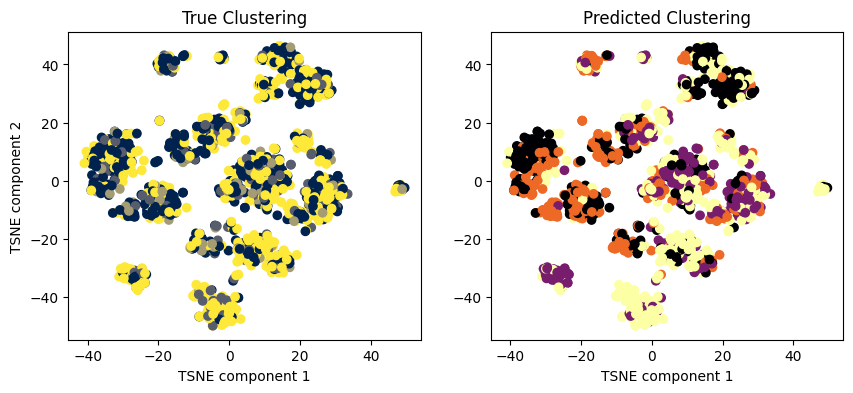

---------------------------- LEIDEN MM ----------------------------


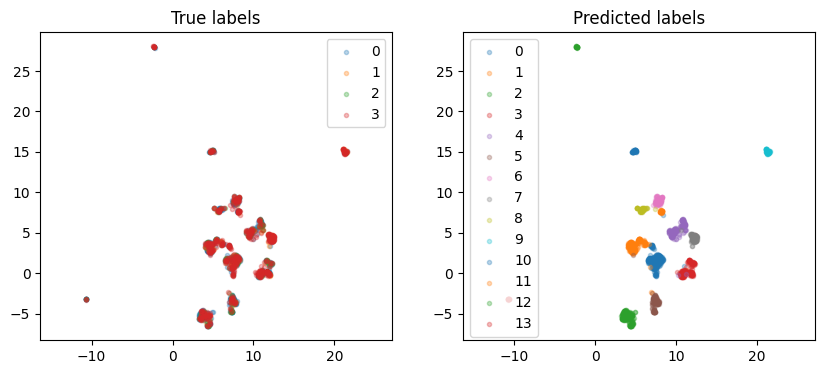

---------------------------- NAIVE BAYES ----------------------------
training accuracy: 29.33%
testing accuracy: 14.81%
None


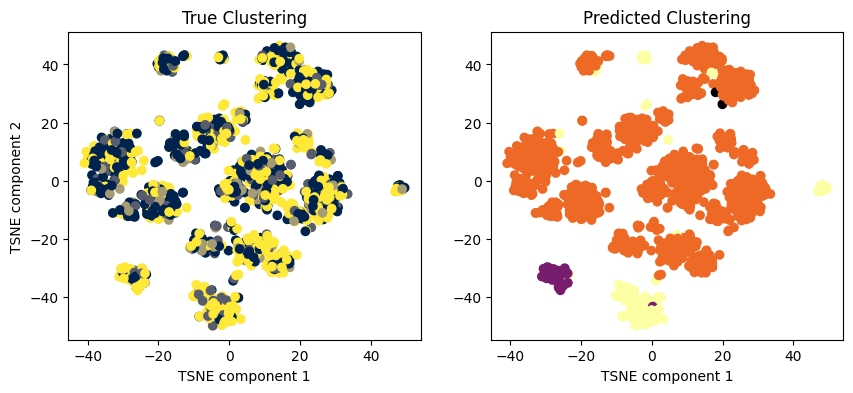

In [98]:
# WITHOUT PCA

print(f'---------------------------- MN LOGISTIC REGRESSION ----------------------------')
MN_LogReg = MN_Logistic_Regression_model(num_classes=4,
                                         x_train=XS_train,
                                         y_train=y_train,
                                         x_test=XS_test,
                                         y_test=y_test,
                                         balance_classes=True)

print(MN_LogReg.get_accuracies())
MN_LogReg.visualize_clustering()


print(f'---------------------------- LEIDEN MM ----------------------------')
Leiden = Leiden_clustering(k=15, 
                            x_data=XS_test,
                            y_data=y_test)

Leiden.get_UMAP()
# params = [0.3, 1.0, 3.0]
# Leiden.run_UMAP_resolutions(params)

print(f'---------------------------- NAIVE BAYES ----------------------------')
NB = Naive_Bayes_model(num_classes=4,
                        x_train=XS_train,
                        y_train=y_train,
                        x_test=XS_test,
                        y_test=y_test,
                        update_priors=True)

print(NB.get_accuracies())
NB.visualize_clustering()

### PCA fit data

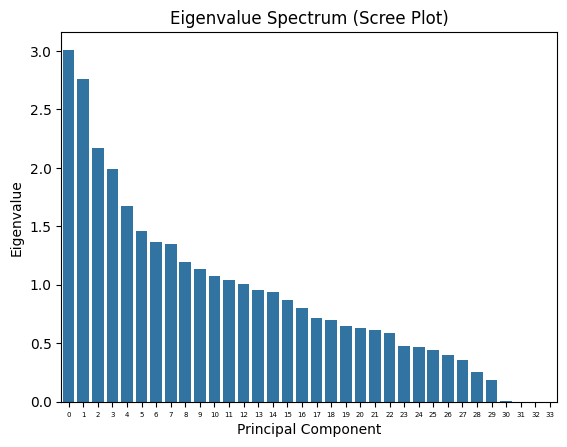

In [99]:
pca = PCA()
pca.fit(XS_train)

# Get eigenvalues (explained variance)
eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

# print("Eigenvalues and explained variance ratio:")
# for i, (ev, ratio) in enumerate(zip(eigenvalues, explained_ratio)):
#     print(f"  PC{i+1}: eigenvalue = {ev:.4f}, explains {ratio*100:.1f}% of variance")
    
# print(f"\nTotal variance explained: {sum(explained_ratio)*100:.1f}%")

# Scree plot
sns.barplot(x=range(len(eigenvalues)), y=eigenvalues)
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalue Spectrum (Scree Plot)')
plt.xticks(fontsize=5)
plt.show()

In [100]:
pca = PCA(n_components=0.97)
X_train_pca = pca.fit_transform(XS_train)
X_test_pca = pca.transform(XS_test)

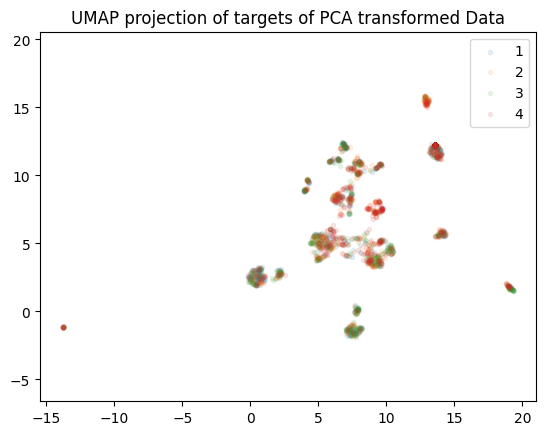

In [101]:
newXY = umap.UMAP().fit_transform(X_train_pca)

for i in range(np.max(y_train) + 1): 
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.', 
                alpha = 0.1, label = str(i + 1))
    
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets of PCA transformed Data')
plt.legend()
plt.show()

---------------------------- MN LOGISTIC REGRESSION ----------------------------
training accuracy: 45.05%
testing accuracy: 47.29%
None


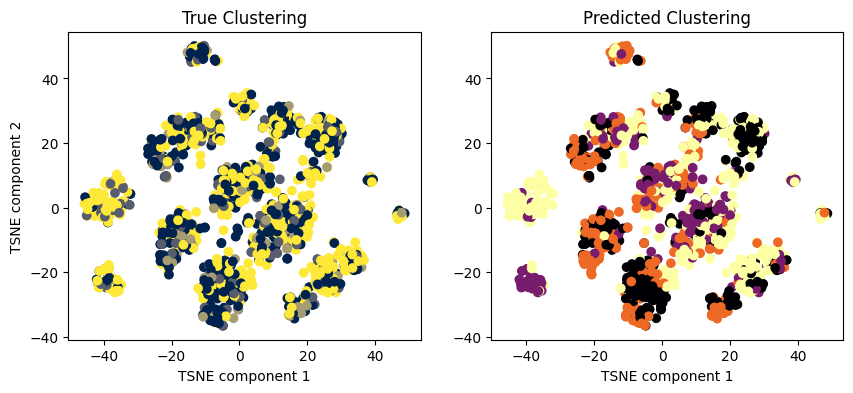

---------------------------- LEIDEN MM ----------------------------


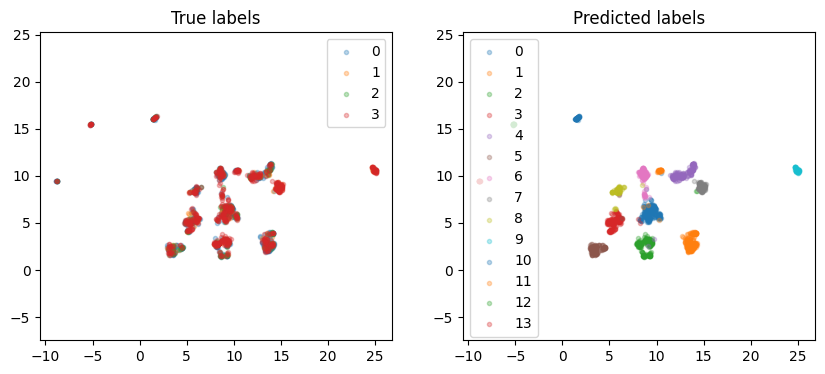

---------------------------- NAIVE BAYES ----------------------------
training accuracy: 40.21%
testing accuracy: 42.60%
None


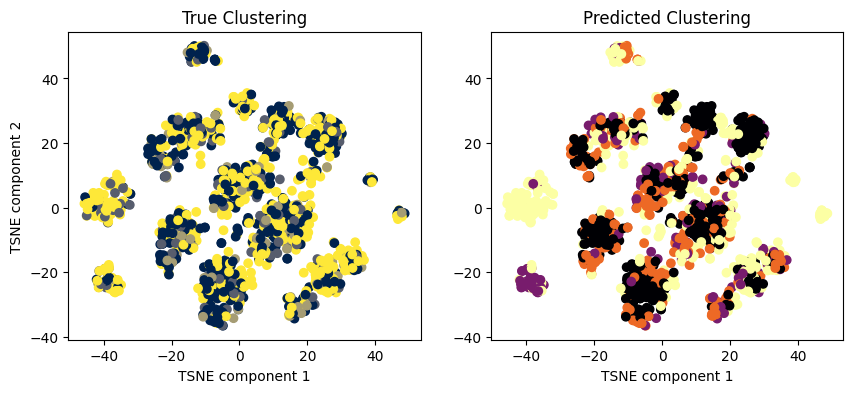

In [102]:
# WITH PCA

print(f'---------------------------- MN LOGISTIC REGRESSION ----------------------------')
MN_LogReg = MN_Logistic_Regression_model(num_classes=4,
                                         x_train=X_train_pca,
                                         y_train=y_train,
                                         x_test=X_test_pca,
                                         y_test=y_test,
                                         balance_classes=True)

print(MN_LogReg.get_accuracies())
MN_LogReg.visualize_clustering()


print(f'---------------------------- LEIDEN MM ----------------------------')
Leiden = Leiden_clustering(k=15, 
                            x_data=X_test_pca,
                            y_data=y_test)

Leiden.get_UMAP()
# params = [0.3, 1.0, 3.0]
# Leiden.run_UMAP_resolutions(params)

print(f'---------------------------- NAIVE BAYES ----------------------------')
NB = Naive_Bayes_model(num_classes=4,
                        x_train=X_train_pca,
                        y_train=y_train,
                        x_test=X_test_pca,
                        y_test=y_test,
                        update_priors=True)

print(NB.get_accuracies())
NB.visualize_clustering()